In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, year, month, avg, max, min, round, expr, first, last
from pyspark.sql.window import Window
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

C:\Users\dioni\anaconda3\envs\data_env\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [21]:
spark = SparkSession.builder \
    .appName("CryptoAnalysis") \
    .getOrCreate()

In [3]:
crypto_files = {
    "BTC": "coin_Bitcoin.csv",
    "ETH": "coin_Ethereum.csv",
    "DOGE": "coin_Dogecoin.csv",
    "USD": "coin_USDcoin.csv",
    "SOL": "coin_Solana.csv"
}

In [4]:
def load_and_process_crypto_data(file_path, crypto_name):
    """Load and preprocess cryptocurrency data"""
    df = spark.read.csv(file_path, header=True, inferSchema=True)
    
    # Data preprocessing
    df = df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd")) \
           .withColumn("Crypto", expr(f"'{crypto_name}'")) \
           .orderBy("Date")
    
    return df

In [5]:
# Load all crypto data
crypto_dfs = []
for crypto, file_name in crypto_files.items():
    file_path = os.path.join(file_name)
    crypto_df = load_and_process_crypto_data(file_path, crypto)
    crypto_dfs.append(crypto_df)

In [6]:
# Combine all data
all_crypto_df = crypto_dfs[0]
for df in crypto_dfs[1:]:
    all_crypto_df = all_crypto_df.union(df)

In [7]:
# Show sample data
print("Sample Data:")
all_crypto_df.show(5)

Sample Data:
+---+-------+------+----------+------------------+------------------+------------------+------------------+------+---------------+------+
|SNo|   Name|Symbol|      Date|              High|               Low|              Open|             Close|Volume|      Marketcap|Crypto|
+---+-------+------+----------+------------------+------------------+------------------+------------------+------+---------------+------+
|  1|Bitcoin|   BTC|2013-04-29|147.48800659179688|             134.0|134.44400024414062| 144.5399932861328|   0.0| 1.6037688645E9|   BTC|
|  2|Bitcoin|   BTC|2013-04-30|146.92999267578125| 134.0500030517578|             144.0|             139.0|   0.0|  1.542813125E9|   BTC|
|  3|Bitcoin|   BTC|2013-05-01|139.88999938964844|107.72000122070312|             139.0|116.98999786376953|   0.0|1.29895459375E9|   BTC|
|  4|Bitcoin|   BTC|2013-05-02| 125.5999984741211| 92.28189849853516|116.37999725341797|105.20999908447266|   0.0|1.16851749525E9|   BTC|
|  5|Bitcoin|   BTC|2

In [8]:
# Monthly average closing price
monthly_avg_close = all_crypto_df.groupBy("Crypto", year("Date").alias("Year"), month("Date").alias("Month")) \
    .agg(avg("Close").alias("AvgClose")) \
    .orderBy("Crypto", "Year", "Month")

print("Monthly Average Closing Price:")
monthly_avg_close.show()

Monthly Average Closing Price:
+------+----+-----+------------------+
|Crypto|Year|Month|          AvgClose|
+------+----+-----+------------------+
|   BTC|2013|    4| 141.7699966430664|
|   BTC|2013|    5|119.99274124637726|
|   BTC|2013|    6|107.76140670776367|
|   BTC|2013|    7|   90.512206539031|
|   BTC|2013|    8|113.90548435334236|
|   BTC|2013|    9| 130.0616668701172|
|   BTC|2013|   10| 158.3119359170237|
|   BTC|2013|   11|  550.420664469401|
|   BTC|2013|   12| 800.7809664818549|
|   BTC|2014|    1| 844.1683900894657|
|   BTC|2014|    2| 661.6182163783482|
|   BTC|2014|    3| 592.2003843245968|
|   BTC|2014|    4|461.36180216471354|
|   BTC|2014|    5| 486.6520031344506|
|   BTC|2014|    6|  615.916737874349|
|   BTC|2014|    7| 618.0250637915826|
|   BTC|2014|    8| 536.0873924993699|
|   BTC|2014|    9| 445.1866007486979|
|   BTC|2014|   10| 364.1488726215978|
|   BTC|2014|   11|366.09979858398435|
+------+----+-----+------------------+
only showing top 20 rows



In [9]:
# Find months with highest and lowest average closing price
window_spec = Window.partitionBy("Crypto")

In [10]:
# Highest closing price months
max_close = monthly_avg_close.withColumn("max_close", max("AvgClose").over(window_spec)) \
    .filter(col("AvgClose") == col("max_close")) \
    .drop("max_close") \
    .orderBy("Crypto")

print("\nMonths with Highest Average Closing Price:")
max_close.show()


Months with Highest Average Closing Price:
+------+----+-----+-------------------+
|Crypto|Year|Month|           AvgClose|
+------+----+-----+-------------------+
|   BTC|2021|    4|  57206.72022674067|
|  DOGE|2021|    5|0.43980041612903226|
|   ETH|2021|    5| 3140.7307596877413|
|   SOL|2021|    5|  39.88682094967743|
|   USD|2018|   12| 1.0145268469305808|
+------+----+-----+-------------------+



In [11]:
# Lowest closing price months
min_close = monthly_avg_close.withColumn("min_close", min("AvgClose").over(window_spec)) \
    .filter(col("AvgClose") == col("min_close")) \
    .drop("min_close") \
    .orderBy("Crypto")

print("\nMonths with Lowest Average Closing Price:")
min_close.show()


Months with Lowest Average Closing Price:
+------+----+-----+--------------------+
|Crypto|Year|Month|            AvgClose|
+------+----+-----+--------------------+
|   BTC|2013|    7|     90.512206539031|
|  DOGE|2015|    4|1.118492191987267...|
|   ETH|2015|   10|  0.6611039330882411|
|   SOL|2020|    5|  0.6033795522227097|
|   USD|2020|    3|  0.9987704054707741|
+------+----+-----+--------------------+



In [12]:
# Calculate daily volatility (High - Low)
volatility_df = all_crypto_df.withColumn("DailyVolatility", col("High") - col("Low"))

In [13]:
# Monthly average volatility
monthly_avg_volatility = volatility_df.groupBy("Crypto", year("Date").alias("Year"), month("Date").alias("Month")) \
    .agg(avg("DailyVolatility").alias("AvgVolatility")) \
    .orderBy("Crypto", "Year", "Month")

print("Monthly Average Volatility:")
monthly_avg_volatility.show()

Monthly Average Volatility:
+------+----+-----+------------------+
|Crypto|Year|Month|     AvgVolatility|
+------+----+-----+------------------+
|   BTC|2013|    4|13.183998107910156|
|   BTC|2013|    5|  9.69558371267011|
|   BTC|2013|    6| 6.697579447428385|
|   BTC|2013|    7| 7.149925724152596|
|   BTC|2013|    8| 4.613774207330519|
|   BTC|2013|    9| 6.788968149820963|
|   BTC|2013|   10|10.796128303773942|
|   BTC|2013|   11| 77.11600443522136|
|   BTC|2013|   12|116.45129000756049|
|   BTC|2014|    1|55.650004725302416|
|   BTC|2014|    2| 58.16357748849051|
|   BTC|2014|    3|31.609197801159276|
|   BTC|2014|    4|32.026666259765626|
|   BTC|2014|    5|17.458390758883567|
|   BTC|2014|    6| 23.43380126953125|
|   BTC|2014|    7|11.236194241431452|
|   BTC|2014|    8| 19.11383745747228|
|   BTC|2014|    9|15.701099650065105|
|   BTC|2014|   10| 19.45761502173639|
|   BTC|2014|   11|19.252403767903647|
+------+----+-----+------------------+
only showing top 20 rows



In [14]:
# Find months with highest and lowest volatility
# Highest volatility months
max_volatility = monthly_avg_volatility.withColumn("max_vol", max("AvgVolatility").over(window_spec)) \
    .filter(col("AvgVolatility") == col("max_vol")) \
    .drop("max_vol") \
    .orderBy("Crypto")

print("\nMonths with Highest Volatility:")
max_volatility.show()


Months with Highest Volatility:
+------+----+-----+-------------------+
|Crypto|Year|Month|      AvgVolatility|
+------+----+-----+-------------------+
|   BTC|2021|    5| 4340.5115227451615|
|  DOGE|2021|    5|0.10951592354838711|
|   ETH|2021|    5|  448.7381456077419|
|   SOL|2021|    5|  7.695149128387096|
|   USD|2020|    3|0.03253751481312902|
+------+----+-----+-------------------+



In [15]:
# Lowest volatility months
min_volatility = monthly_avg_volatility.withColumn("min_vol", min("AvgVolatility").over(window_spec)) \
    .filter(col("AvgVolatility") == col("min_vol")) \
    .drop("min_vol") \
    .orderBy("Crypto")

print("\nMonths with Lowest Volatility:")
min_volatility.show()


Months with Lowest Volatility:
+------+----+-----+--------------------+
|Crypto|Year|Month|       AvgVolatility|
+------+----+-----+--------------------+
|   BTC|2013|    8|   4.613774207330519|
|  DOGE|2015|    9|4.780332286221286E-6|
|   ETH|2015|   12| 0.05213286799769248|
|   SOL|2020|    5|0.054319735394838684|
|   USD|2021|    5|8.729348387096849E-4|
+------+----+-----+--------------------+



In [16]:
# Calculate yearly growth percentage
yearly_prices = all_crypto_df.groupBy("Crypto", year("Date").alias("Year")) \
    .agg(
        first("Close").alias("FirstClose"),
        last("Close").alias("LastClose")
    ) \
    .orderBy("Crypto", "Year")

In [17]:
# Calculate growth percentage
yearly_growth = yearly_prices.withColumn(
    "GrowthPercentage", 
    round(((col("LastClose") - col("FirstClose")) / col("FirstClose")) * 100, 2)
)
print("Yearly Growth Percentage:")
yearly_growth.show()

Yearly Growth Percentage:
+------+----+--------------------+--------------------+----------------+
|Crypto|Year|          FirstClose|           LastClose|GrowthPercentage|
+------+----+--------------------+--------------------+----------------+
|   BTC|2013|   144.5399932861328|    754.010009765625|          421.66|
|   BTC|2014|   771.4000244140625|   320.1929931640625|          -58.49|
|   BTC|2015|   314.2489929199219|   430.5669860839844|           37.01|
|   BTC|2016|   434.3340148925781|   963.7429809570312|          121.89|
|   BTC|2017|   998.3250122070312|     14156.400390625|         1318.02|
|   BTC|2018|    13657.2001953125|       3742.70033544|           -72.6|
|   BTC|2019|       3843.51996727|       7193.59897843|           87.16|
|   BTC|2020|       7200.17439274|      29001.71982218|          302.79|
|   BTC|2021|      29374.15188907|      34235.19345116|           16.55|
|  DOGE|2013|2.047309972112998...|4.222459974698722...|          106.24|
|  DOGE|2014|4.3969799298

In [18]:
# Most consistent growth crypto
consistent_growth = yearly_growth.filter(col("GrowthPercentage") > 0) \
    .groupBy("Crypto") \
    .count() \
    .orderBy(col("count").desc()) \
    .limit(1)

print("Crypto with Most Consistent Growth:")
consistent_growth.show()

Crypto with Most Consistent Growth:
+------+-----+
|Crypto|count|
+------+-----+
|   BTC|    7|
+------+-----+



In [19]:
# Highest volatility crypto
overall_volatility = monthly_avg_volatility.groupBy("Crypto") \
    .agg(avg("AvgVolatility").alias("OverallAvgVolatility")) \
    .orderBy(col("OverallAvgVolatility").desc()) \
    .limit(1)

print("\nCrypto with Highest Overall Volatility:")
overall_volatility.show()


Crypto with Highest Overall Volatility:
+------+--------------------+
|Crypto|OverallAvgVolatility|
+------+--------------------+
|   BTC|   414.8383111074122|
+------+--------------------+



In [20]:
# Convert Spark DataFrame to Pandas for visualization
monthly_avg_close_pd = monthly_avg_close.toPandas()
yearly_growth_pd = yearly_growth.toPandas()

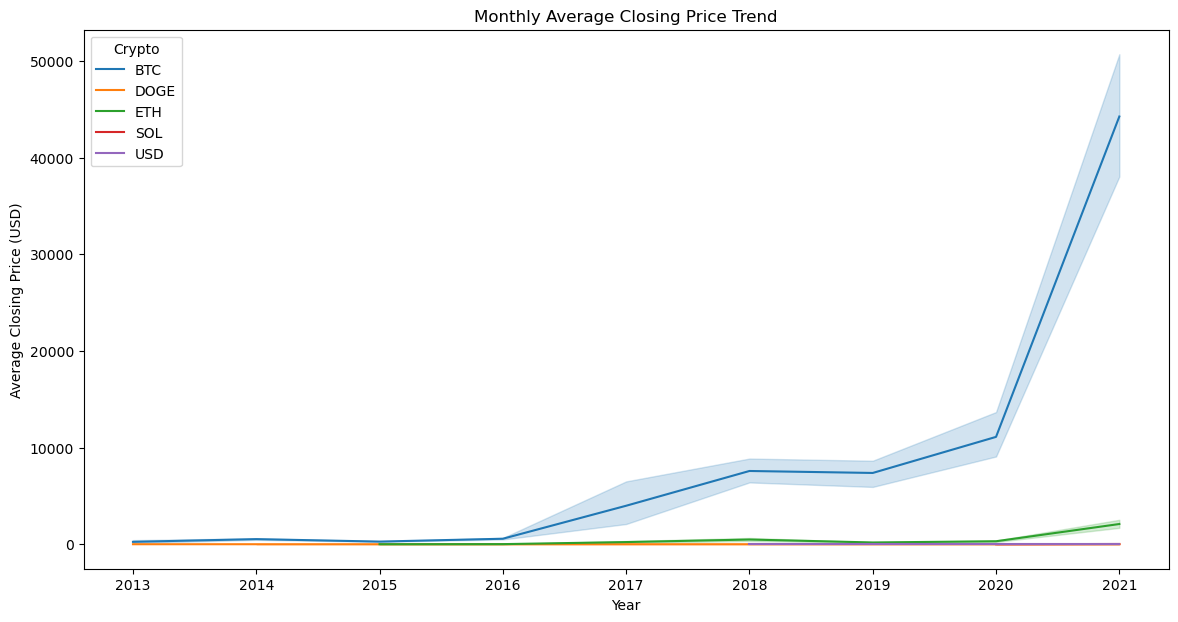

In [22]:
# Plot monthly average closing price
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_avg_close_pd, x="Year", y="AvgClose", hue="Crypto")
plt.title("Monthly Average Closing Price Trend")
plt.ylabel("Average Closing Price (USD)")
plt.show()

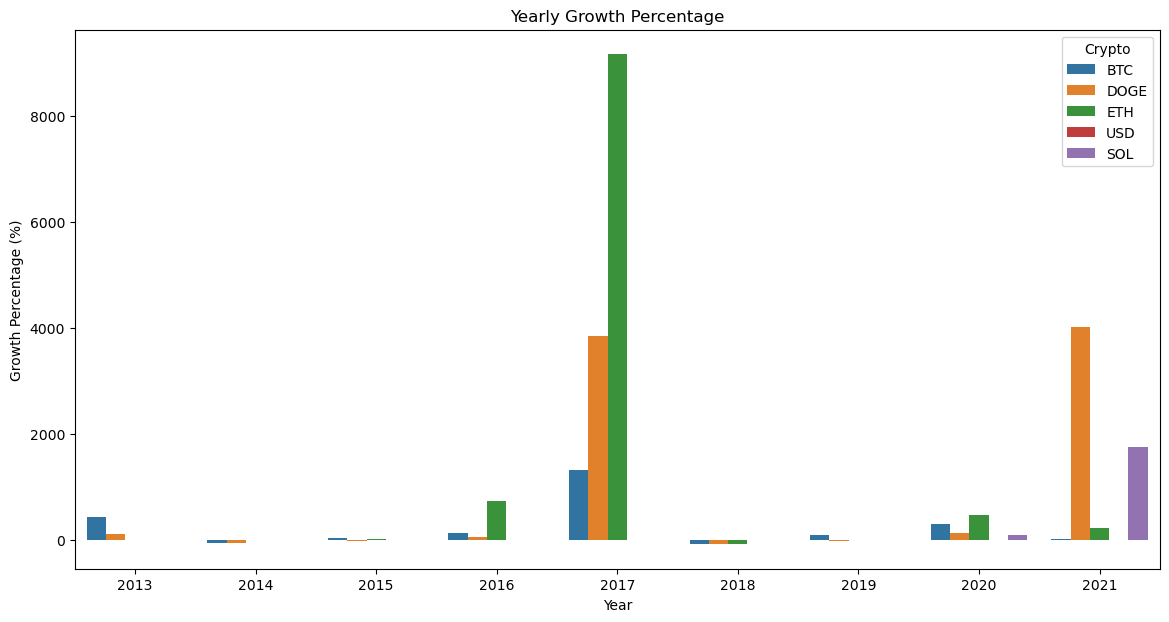

In [23]:
# Plot yearly growth percentage
plt.figure(figsize=(14, 7))
sns.barplot(data=yearly_growth_pd, x="Year", y="GrowthPercentage", hue="Crypto")
plt.title("Yearly Growth Percentage")
plt.ylabel("Growth Percentage (%)")
plt.show()

In [25]:
# Get stats for recommendations
growth_stats = yearly_growth.groupBy("Crypto").agg(
    avg("GrowthPercentage").alias("AvgYearlyGrowth"),
    min("GrowthPercentage").alias("MinYearlyGrowth"),
    max("GrowthPercentage").alias("MaxYearlyGrowth")
).collect()

volatility_stats = monthly_avg_volatility.groupBy("Crypto").agg(
    avg("AvgVolatility").alias("AvgVolatility")
).collect()

In [26]:
# Generate recommendations
print("Investment Recommendations:")
for crypto in crypto_files.keys():
    # Growth data
    growth_data = [x for x in growth_stats if x["Crypto"] == crypto][0]
    avg_growth = growth_data["AvgYearlyGrowth"]
    min_growth = growth_data["MinYearlyGrowth"]
    max_growth = growth_data["MaxYearlyGrowth"]
    
    # Volatility data
    vol_data = [x for x in volatility_stats if x["Crypto"] == crypto][0]
    avg_vol = vol_data["AvgVolatility"]
    
    print(f"\n**{crypto} Analysis:**")
    print(f"- Average yearly growth: {avg_growth:.2f}%")
    print(f"- Growth range: {min_growth:.2f}% to {max_growth:.2f}%")
    print(f"- Average volatility: {avg_vol:.2f}")

Investment Recommendations:

**BTC Analysis:**
- Average yearly growth: 241.55%
- Growth range: -72.60% to 1318.02%
- Average volatility: 414.84

**ETH Analysis:**
- Average yearly growth: 1502.23%
- Growth range: -82.74% to 9159.42%
- Average volatility: 34.04

**DOGE Analysis:**
- Average yearly growth: 886.53%
- Growth range: -73.67% to 4023.54%
- Average volatility: 0.00

**USD Analysis:**
- Average yearly growth: -0.10%
- Growth range: -0.94% to 0.96%
- Average volatility: 0.01

**SOL Analysis:**
- Average yearly growth: 927.42%
- Growth range: 94.50% to 1760.35%
- Average volatility: 1.55


In [31]:
# Recommendations
print("\nRecommendation:")
if avg_growth > 50 and avg_vol > 50:
    print("High-growth, high-volatility asset. Suitable for long-term investment with high risk tolerance. Not recommended for short-term trading unless experienced.")
elif avg_growth > 30 and avg_vol < 50:
    print("Good growth with moderate volatility. Suitable for medium to long-term investment. Can consider for short-term trading with proper risk management.")
elif avg_growth > 0 and avg_vol < 30:
    print("Stable growth with low volatility. Suitable for conservative investors looking for crypto exposure with minimal risk.")
else:
    print("Performance varies. Requires deeper analysis before investment decisions.")


Recommendation:
Good growth with moderate volatility. Suitable for medium to long-term investment. Can consider for short-term trading with proper risk management.
